# Frequency Analysis of Motor Imagery EEG

## Research Question

Do the spectral characteristics of EEG differ between left- and right-hand motor imagery?

## Hypothesis

Motor imagery is expected to modulate sensorimotor rhythms, particularly in the mu (approximately 8–13 Hz) and beta (approximately 13–30 Hz) frequency ranges.

We therefore focus on the sensorimotor electrodes C3, Cz, and C4 and compare spectral power between left- and right-hand motor imagery trials.

In [5]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# مسیر فایل را با توجه به ساختار پروژه‌ی خود تنظیم کنید
file_path = "../data/raw/S001R04.edf" 
raw = mne.io.read_raw_edf(file_path, preload=True)

Extracting EDF parameters from ../data/raw/S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...


In [6]:
# کپی گرفتن از داده برای جلوگیری از تغییرات ناخواسته
raw_avg_ref = raw.copy()

# اعمال رفرنس میانگین (Average Reference)
raw_avg_ref.set_eeg_reference(ref_channels="average")

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

In [7]:
# فیلتر باند-پس ۸ تا ۳۰ هرتز برای تمرکز روی مو و بتا
raw_avg_ref.filter(l_freq=8.0, h_freq=30.0)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)



<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

In [13]:
def standardize_channel_name(name):
    # حذف تمام نقاط اضافی از انتهای نام
    return name.rstrip('.')

In [14]:
raw_avg_ref.rename_channels(standardize_channel_name)

<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

In [15]:
print("C3 index:", raw_avg_ref.ch_names.index("C3"))
print("Cz index:", raw_avg_ref.ch_names.index("Cz"))
print("C4 index:", raw_avg_ref.ch_names.index("C4"))

C3 index: 8
Cz index: 10
C4 index: 12


In [16]:
sensorimotor_channels = ["C3", "Cz", "C4"]

print(sensorimotor_channels)

['C3', 'Cz', 'C4']


In [17]:
events, event_id = mne.events_from_annotations(raw_avg_ref)

event_id_mi = {
    "Left": event_id["T1"],
    "Right": event_id["T2"]
}

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]


In [18]:
epochs_freq = mne.Epochs(
    raw_avg_ref,
    events,
    event_id=event_id_mi,
    tmin=1.0,
    tmax=4.0,
    baseline=None,
    preload=True
)

Not setting metadata
15 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 15 events and 481 original time points ...
0 bad epochs dropped


In [19]:
print(epochs_freq)

<Epochs | 15 events (all good), 1 – 4 s (baseline off), ~3.6 MiB, data loaded,
 'Left': 8
 'Right': 7>


In [20]:
psd_c3 = epochs_freq["Left"].compute_psd(
    method="welch",
    fmin=4,
    fmax=40,
    picks=["C3"],
    tmin=1,
    tmax=4,
    n_per_seg=256,
    n_overlap=128
)

Effective window size : 3.006 (s)


In [21]:
psds_c3 = psd_c3.get_data()
freqs = psd_c3.freqs

print("PSD shape:", psds_c3.shape)
print("Frequency range:", freqs[0], "to", freqs[-1], "Hz")

PSD shape: (8, 1, 108)
Frequency range: 4.324324324324325 to 39.91683991683992 Hz


In [22]:
mean_psd_c3_left = psds_c3.mean(axis=0).squeeze()


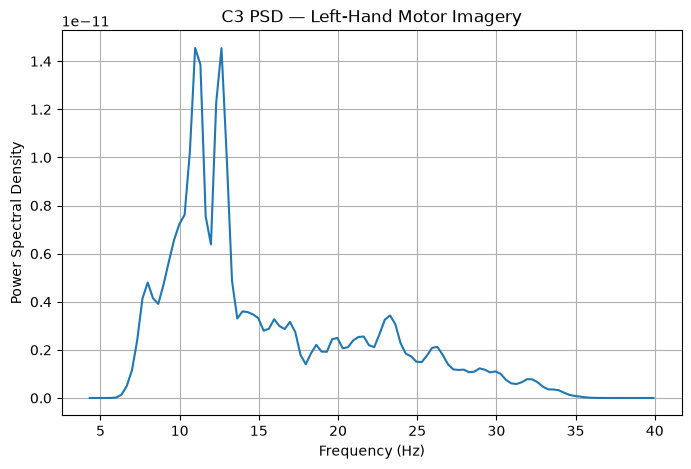

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    freqs,
    mean_psd_c3_left
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title("C3 PSD — Left-Hand Motor Imagery")

plt.grid(True)
plt.show()

In [26]:
psd_c3_right = epochs_freq["Right"].compute_psd(
    method="welch",
    fmin=4,
    fmax=40,
    picks=["C3"],
    tmin=1,
    tmax=4,
    n_per_seg=256,
    n_overlap=128
)

Effective window size : 3.006 (s)


In [27]:
psds_c3_right = psd_c3_right.get_data()

mean_psd_c3_right = psds_c3_right.mean(
    axis=0
).squeeze()

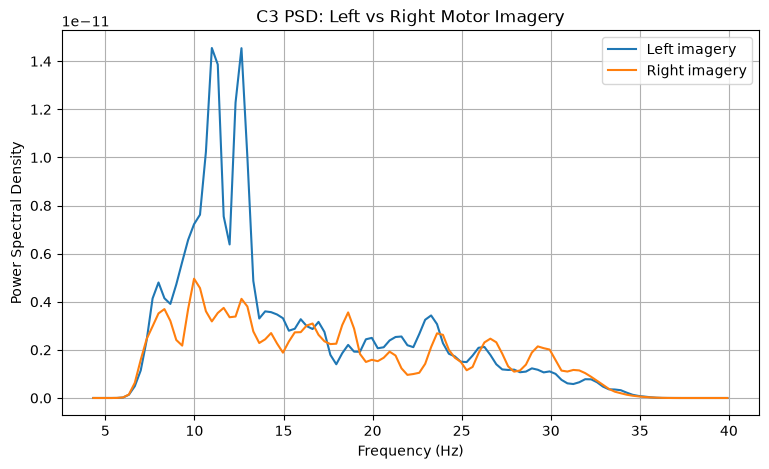

In [28]:
plt.figure(figsize=(9, 5))

plt.plot(
    freqs,
    mean_psd_c3_left,
    label="Left imagery"
)

plt.plot(
    psd_c3_right.freqs,
    mean_psd_c3_right,
    label="Right imagery"
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title("C3 PSD: Left vs Right Motor Imagery")

plt.legend()
plt.grid(True)

plt.show()

In [29]:
def compute_mean_psd(epochs, condition, channel):
    spectrum = epochs[condition].compute_psd(
        method="welch",
        fmin=4,
        fmax=40,
        picks=[channel],
        tmin=1,
        tmax=4,
        n_per_seg=256,
        n_overlap=128
    )

    psds = spectrum.get_data()

    mean_psd = psds.mean(axis=0).squeeze()

    return spectrum.freqs, mean_psd

In [30]:
channels = ["C3", "Cz", "C4"]

psd_results = {}

for channel in channels:

    freqs_left, psd_left = compute_mean_psd(
        epochs_freq,
        "Left",
        channel
    )

    freqs_right, psd_right = compute_mean_psd(
        epochs_freq,
        "Right",
        channel
    )

    psd_results[channel] = {
        "freqs": freqs_left,
        "left": psd_left,
        "right": psd_right
    }

Effective window size : 3.006 (s)
Effective window size : 3.006 (s)
Effective window size : 3.006 (s)
Effective window size : 3.006 (s)
Effective window size : 3.006 (s)
Effective window size : 3.006 (s)


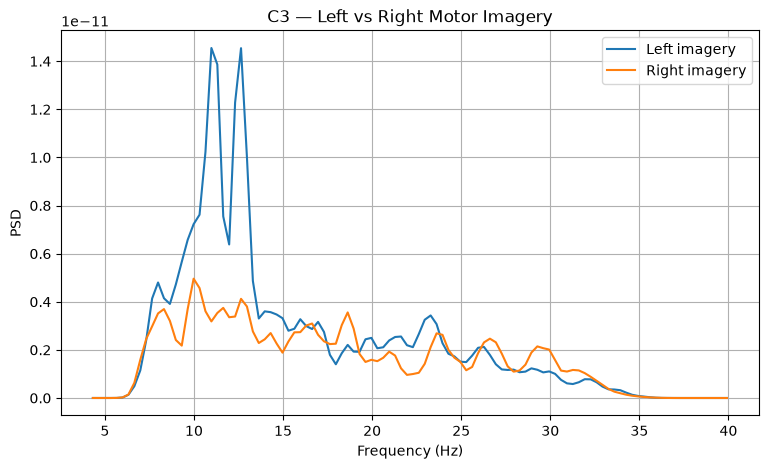

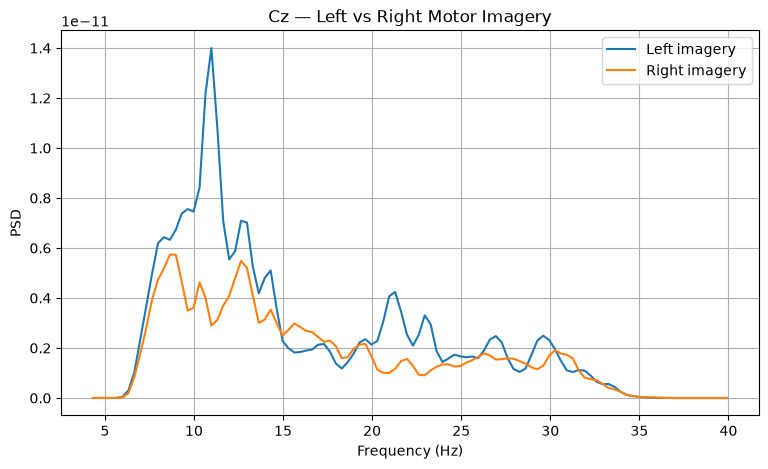

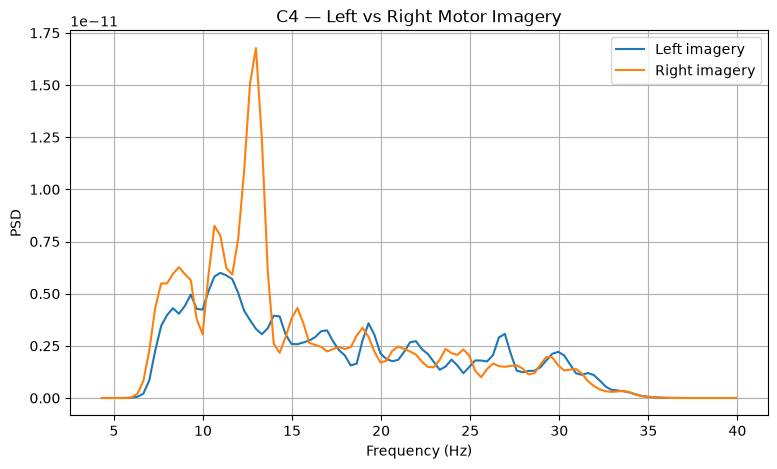

In [31]:
for channel in channels:

    plt.figure(figsize=(9, 5))

    plt.plot(
        psd_results[channel]["freqs"],
        psd_results[channel]["left"],
        label="Left imagery"
    )

    plt.plot(
        psd_results[channel]["freqs"],
        psd_results[channel]["right"],
        label="Right imagery"
    )

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("PSD")

    plt.title(
        f"{channel} — Left vs Right Motor Imagery"
    )

    plt.legend()
    plt.grid(True)

    plt.show()

In [32]:
def band_power(freqs, psd, fmin, fmax):

    mask = (
        (freqs >= fmin) &
        (freqs <= fmax)
    )

    return np.trapezoid(
        psd[mask],
        freqs[mask]
    )

In [33]:
c3_left_mu = band_power(
    freqs,
    mean_psd_c3_left,
    8,
    13
)

c3_right_mu = band_power(
    psd_c3_right.freqs,
    mean_psd_c3_right,
    8,
    13
)

c3_left_beta = band_power(
    freqs,
    mean_psd_c3_left,
    13,
    30
)

c3_right_beta = band_power(
    psd_c3_right.freqs,
    mean_psd_c3_right,
    13,
    30
)

In [34]:
print("C3 Mu power")
print("Left :", c3_left_mu)
print("Right:", c3_right_mu)

print()

print("C3 Beta power")
print("Left :", c3_left_beta)
print("Right:", c3_right_beta)

C3 Mu power
Left : 4.064374161713436e-11
Right: 1.6535419813667665e-11

C3 Beta power
Left : 3.745120877666006e-11
Right: 3.3667971654275195e-11


In [35]:
for channel in ["C3", "C4"]:

    freqs_left, psd_left = compute_mean_psd(
        epochs_freq,
        "Left",
        channel
    )

    freqs_right, psd_right = compute_mean_psd(
        epochs_freq,
        "Right",
        channel
    )

    left_mu = band_power(
        freqs_left,
        psd_left,
        8,
        13
    )

    right_mu = band_power(
        freqs_right,
        psd_right,
        8,
        13
    )

    print(f"\nChannel: {channel}")

    print("Left imagery mu power :", left_mu)
    print("Right imagery mu power:", right_mu)

Effective window size : 3.006 (s)
Effective window size : 3.006 (s)

Channel: C3
Left imagery mu power : 4.064374161713436e-11
Right imagery mu power: 1.6535419813667665e-11
Effective window size : 3.006 (s)
Effective window size : 3.006 (s)

Channel: C4
Left imagery mu power : 2.2354868075601527e-11
Right imagery mu power: 3.449889915155171e-11


In [36]:
def compute_band_power_per_trial(
    epochs,
    condition,
    channel,
    fmin,
    fmax
):

    spectrum = epochs[condition].compute_psd(
        method="welch",
        fmin=4,
        fmax=40,
        picks=[channel],
        tmin=1,
        tmax=4,
        n_per_seg=256,
        n_overlap=128
    )

    psds = spectrum.get_data()

    freqs = spectrum.freqs

    powers = []

    for psd in psds:

        psd = psd.squeeze()

        power = band_power(
            freqs,
            psd,
            fmin,
            fmax
        )

        powers.append(power)

    return np.array(powers)

In [37]:
c3_left_mu_trials = compute_band_power_per_trial(
    epochs_freq,
    "Left",
    "C3",
    8,
    13
)

c3_right_mu_trials = compute_band_power_per_trial(
    epochs_freq,
    "Right",
    "C3",
    8,
    13
)

Effective window size : 3.006 (s)
Effective window size : 3.006 (s)


In [38]:
print(
    "Left trials:",
    len(c3_left_mu_trials)
)

print(
    "Right trials:",
    len(c3_right_mu_trials)
)

Left trials: 8
Right trials: 7


In [39]:
# میانگین و انحراف معیار
print("C3 Mu")

print(
    "Left mean:",
    c3_left_mu_trials.mean()
)

print(
    "Left std:",
    c3_left_mu_trials.std()
)

print(
    "Right mean:",
    c3_right_mu_trials.mean()
)

print(
    "Right std:",
    c3_right_mu_trials.std()
)

C3 Mu
Left mean: 4.064374161713436e-11
Left std: 2.6205437599636098e-11
Right mean: 1.6535419813667665e-11
Right std: 3.5428224179333942e-12


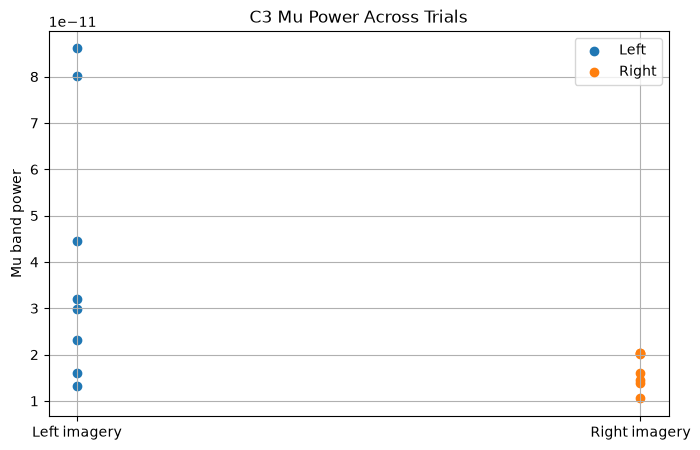

In [40]:
plt.figure(figsize=(8, 5))

plt.scatter(
    np.zeros(len(c3_left_mu_trials)),
    c3_left_mu_trials,
    label="Left"
)

plt.scatter(
    np.ones(len(c3_right_mu_trials)),
    c3_right_mu_trials,
    label="Right"
)

plt.xticks(
    [0, 1],
    ["Left imagery", "Right imagery"]
)

plt.ylabel("Mu band power")
plt.title("C3 Mu Power Across Trials")

plt.legend()
plt.grid(True)

plt.show()

In [41]:
spectrum_left = epochs_freq["Left"].compute_psd(
    method="welch",
    fmin=8,
    fmax=30,
    picks="eeg",
    tmin=1,
    tmax=4,
    n_per_seg=256,
    n_overlap=128
)

Effective window size : 3.006 (s)


In [42]:
psds_left = spectrum_left.get_data()

mean_psd_left = psds_left.mean(axis=0)

In [43]:
freqs = spectrum_left.freqs

mu_mask = (
    (freqs >= 8) &
    (freqs <= 13)
)

mu_power_left = np.trapezoid(
    mean_psd_left[:, mu_mask],
    freqs[mu_mask],
    axis=1
)

In [45]:
mne.viz.plot_topomap(
    mu_power_left,
    spectrum_left.info,
    show_names=True
)

plt.title("Mu Power — Left Motor Imagery")
plt.show()


TypeError: plot_topomap() got an unexpected keyword argument 'show_names'

In [46]:
spectrum_right = epochs_freq["Right"].compute_psd(
    method="welch",
    fmin=8,
    fmax=30,
    picks="eeg",
    tmin=1,
    tmax=4,
    n_per_seg=256,
    n_overlap=128
)

psds_right = spectrum_right.get_data()

mean_psd_right = psds_right.mean(axis=0)

freqs_right = spectrum_right.freqs

mu_mask_right = (
    (freqs_right >= 8) &
    (freqs_right <= 13)
)

mu_power_right = np.trapezoid(
    mean_psd_right[:, mu_mask_right],
    freqs_right[mu_mask_right],
    axis=1
)

Effective window size : 3.006 (s)


In [47]:
mne.viz.plot_topomap(
    mu_power_right,
    spectrum_right.info,
    show_names=True
)

plt.title("Mu Power — Right Motor Imagery")
plt.show()

TypeError: plot_topomap() got an unexpected keyword argument 'show_names'

In [48]:
# Epoch مخصوص ERD/ERS
epochs_erd = mne.Epochs(
    raw_filtered,
    events,
    event_id=event_id_mi,
    tmin=-1.0,
    tmax=4.0,
    baseline=(-1.0, 0.0),
    preload=True
)

NameError: name 'raw_filtered' is not defined